# Дерево, лес (обычные и косые)

Есть картинка, каждый пиксель превращается в точку `(x, y)`, а цвет пикселя становится классом `0` или `1`

In [4]:
# Библиотеки: массивы, графики, метрики и готовые модели и методы для работы с ними
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

np.random.seed(42) # для воспроизводимости

Сделаем простую бинарную картинку. Черное это класс `1`, белое это класс `0`

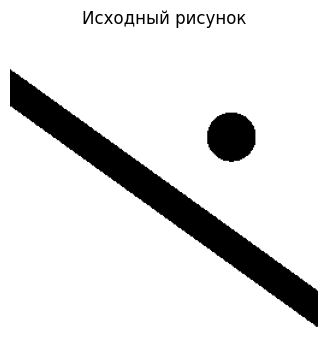

In [5]:
size = 256

# Сетка координат
yy, xx = np.mgrid[0:size, 0:size]
x = xx / (size - 1)
y = yy / (size - 1)

# Рисунок с наклонами, чтобы обычным деревьям было сложнее
line = np.abs(y - (0.18 + 0.72 * x)) < 0.06
circle = (x - 0.72) ** 2 + (y - 0.34) ** 2 < 0.08 ** 2
picture = (line | circle)

# Что у нас получилось
plt.figure(figsize=(4, 4))
plt.imshow(picture, cmap="gray_r")
plt.axis("off")
plt.title("Исходный рисунок");

Теперь превращаем пиксели в таблицу. Так как фона слишком много, если сравнивать по точкам, то берем одинаковое число черных и белых пикселей

In [ ]:
# X_all это координаты всех пикселей, y_all это их классы.
X_all = np.c_[x.ravel(), y.ravel()]
y_all = picture.ravel()

# Берем поровну точек фона и рисунка, чтобы классы были сбалансированы
pos = np.where(y_all == 1)[0]
neg = np.where(y_all == 0)[0]
n = min(len(pos), len(neg), 5000)

idx = np.r_[np.random.choice(pos, n, replace=False), np.random.choice(neg, n, replace=False)]
np.random.shuffle(idx)

X_data = X_all[idx]
y_data = y_all[idx]

# Делим данные на обучение и тест
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, train_size=0.7, stratify=y_data, random_state=42)

X_train.shape, X_test.shape

((7000, 2), (3000, 2))

Обучим обычное дерево и случайный лес из sklearn

In [ ]:
# Обычное дерево делает разбиения только по x или только по y
tree = DecisionTreeClassifier(max_depth=7, min_samples_leaf=8, random_state=42)

# Лес обучает много деревьев и усредняет их
forest = RandomForestClassifier(n_estimators=40, max_depth=7,
                                min_samples_leaf=8, bootstrap=True, random_state=42)

# Обучаем модели
tree.fit(X_train, y_train)
forest.fit(X_train, y_train);

В sklearn нет готовой реализации косого решающего дерева. Поэтому здесь мы сами добавим признаки вида `a*x + b*y`

In [ ]:
def add_oblique_features(X, n_directions=40):
    # Каждое направление это проекция точки на наклонную ось
    angles = np.linspace(0, np.pi, n_directions, endpoint=False)
    directions = np.c_[np.cos(angles), np.sin(angles)]
    projections = X @ directions.T
    return np.c_[X, projections]

# Добавим новые признаки
X_train_oblique = add_oblique_features(X_train)
X_test_oblique = add_oblique_features(X_test)
X_all_oblique = add_oblique_features(X_all)

# Косые версии дерева и леса
oblique_tree = DecisionTreeClassifier(max_depth=7, min_samples_leaf=8, random_state=42)
oblique_forest = RandomForestClassifier(n_estimators=40, max_depth=7,
                                min_samples_leaf=8, bootstrap=True, random_state=42)

# Обучаем модели на новых признаках
oblique_tree.fit(X_train_oblique, y_train)
oblique_forest.fit(X_train_oblique, y_train);

Посчитаем базовые метрики. Они не заменяют картинку, но помогают увидеть разницу численно

In [ ]:
# Словарь: модель, версия тестовой выборки
models = {"Decision tree": (tree, X_test), "Random forest": (forest, X_test),
    "Oblique tree": (oblique_tree, X_test_oblique), "Oblique forest": (oblique_forest, X_test_oblique)}

for name, (model, X_eval) in models.items():
    # predict возвращает готовые классы: 0 для фона и 1 для рисунка
    pred = model.predict(X_eval)
    print(name)
    print("accuracy ", round(accuracy_score(y_test, pred), 3))
    print("precision", round(precision_score(y_test, pred), 3))
    print("recall   ", round(recall_score(y_test, pred), 3))
    print("f1       ", round(f1_score(y_test, pred), 3))
    print()

Decision tree
accuracy  0.839
precision 0.766
recall    0.977
f1        0.859

Random forest
accuracy  0.913
precision 0.853
recall    0.997
f1        0.92

Oblique tree
accuracy  0.995
precision 0.993
recall    0.997
f1        0.995

Oblique forest
accuracy  0.997
precision 0.994
recall    0.999
f1        0.997



После обучения модель можно использовать на новых точках. Например, спросим oblique forest про несколько новых точек

[0.2  0.32] -> рисунок
[0.72 0.34] -> рисунок
[0.1 0.9] -> фон


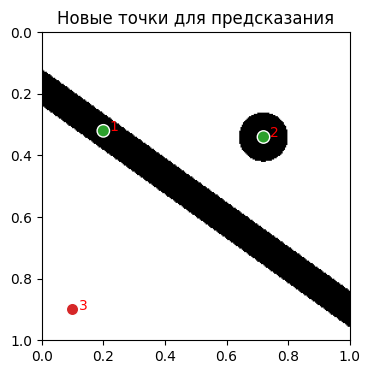

In [ ]:
# Несколько новых точек: каждая строка это координаты x и y
new_points = np.array([[0.20, 0.32],[0.72, 0.34],[0.10, 0.90]])

# Не забываем про oblique-признаки
new_points_oblique = add_oblique_features(new_points)
new_pred = oblique_forest.predict(new_points_oblique)

for point, label in zip(new_points, new_pred):
    print(point, "->", "рисунок" if label == 1 else "фон")

# Покажем эти точки на исходном рисунке
point_colors = ["tab:green" if label == 1 else "tab:red" for label in new_pred]

plt.figure(figsize=(4, 4))
plt.imshow(picture, cmap="gray_r", extent=[0, 1, 1, 0])
plt.scatter(new_points[:, 0], new_points[:, 1], c=point_colors, s=80, edgecolors="white")

for i, point in enumerate(new_points, 1):
    plt.text(point[0] + 0.02, point[1], str(i), color="red")

plt.title("Новые точки")
plt.xlim(0, 1)
plt.ylim(1, 0)
plt.show();

Теперь восстановим весь рисунок. То есть попросим модель дать ответ для каждого пикселя сетки 256 на 256

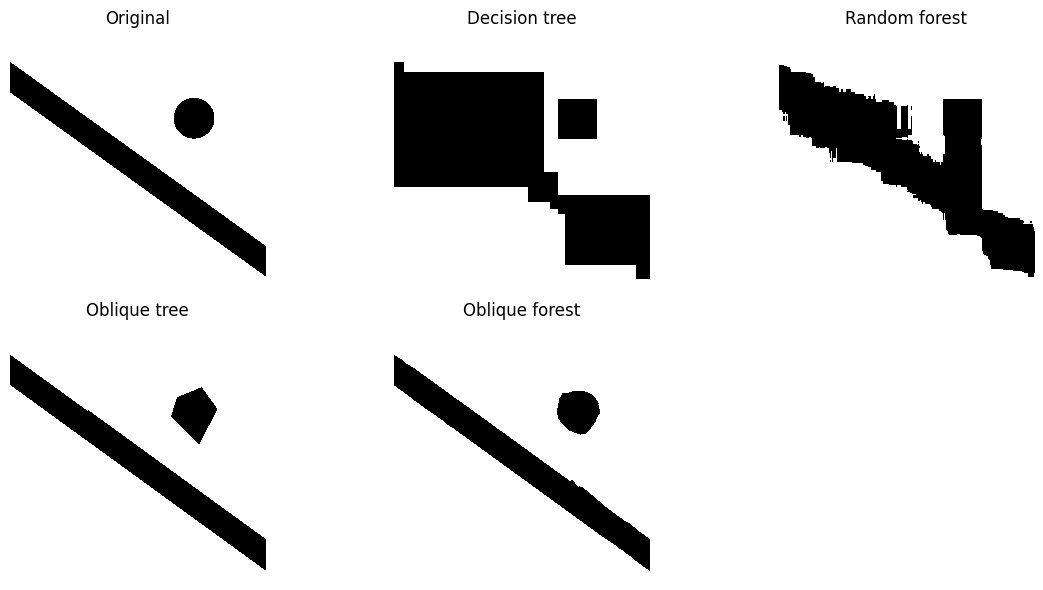

In [ ]:
def restore(model, X_grid):
    # Предсказываем класс для каждого пикселя и возвращаем форму картинки
    return model.predict(X_grid).reshape(size, size)

restored = {"Original": picture, "Decision tree": restore(tree, X_all),
            "Random forest": restore(forest, X_all),
            "Oblique tree": restore(oblique_tree, X_all_oblique), 
            "Oblique forest": restore(oblique_forest, X_all_oblique)}

# Сравним исходную картинку и ответы моделей
plt.figure(figsize=(12, 6))
for i, (name, img) in enumerate(restored.items(), 1):
    plt.subplot(2, 3, i)
    plt.imshow(img, cmap="gray_r")
    plt.title(name)
    plt.axis("off")
plt.tight_layout();

Посмотрим на матрицу ошибок для лучшей модели в этом примере

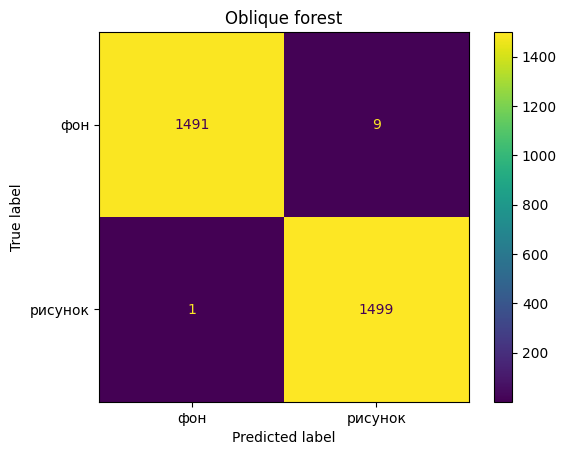

In [ ]:
# Матрица показывает, где модель угадала, а где перепутала фон и рисунок
best_pred = oblique_forest.predict(X_test_oblique)
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, display_labels=["фон", "рисунок"])
plt.title("Oblique forest")
plt.show();

Короткий вывод: обычное дерево строит прямоугольные грубоватые границы. Лес обычно стабильнее из-за усреднения, но не дообучился. Oblique-признаки помогают дереву делать наклонные разбиения, из-за чего проще восстанавливать нетривиальные части рисунка